# Домашнее задание №2. Сегментация клиентов немецкого банка

**Задача:** познакомиться с клиентской базой, построить K-Means, иерархическую кластеризацию и DBSCAN, сравнить качество разбиений, визуализировать их с помощью PCA, UMAP и t-SNE и интерпретировать найденные сегменты.

Данные: локальная копия [`german_credit_data.csv`](https://www.kaggle.com/datasets/uciml/german-credit), 1000 клиентов German Credit Data.

Краткая схема решения:

1. EDA и проверка качества данных.
2. Удаление технического индекса, обработка пропусков, one-hot кодирование категорий и стандартизация числовых признаков.
3. Подбор K-Means по elbow и silhouette; иерархической модели — по дендрограмме и silhouette; DBSCAN — по k-distance curve и ограниченному перебору `eps`/`min_samples`.
4. PCA, UMAP и t-SNE только для двумерной визуализации (модели обучаются на полном обработанном пространстве).
5. Профилирование наиболее устойчивого решения и бизнес-интерпретация.

> Кластеризация является обучением без учителя: «истинных» меток здесь нет. Поэтому выводы основаны на внутренних метриках, устойчивости и интерпретируемости, а не на accuracy.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path

get_ipython().run_line_magic("matplotlib", "inline")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.stats import chi2_contingency

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 13

## Часть 1. EDA и preprocessing

In [2]:
DATA_PATH = Path("german_credit_data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Положите german_credit_data.csv в одну папку с ноутбуком."
    )

raw = pd.read_csv(DATA_PATH)
df = raw.copy()
print(f"Размер исходной таблицы: {df.shape[0]} строк × {df.shape[1]} столбцов")
display(df.head())

Размер исходной таблицы: 1000 строк × 10 столбцов


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [3]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean().mul(100).round(1),
    "n_unique": df.nunique(dropna=True),
})
display(audit)

print(f"Полных дубликатов: {df.duplicated().sum()}")
print(f"Уникальных значений в Unnamed: 0: {df['Unnamed: 0'].nunique()}")

,dtype,missing,missing_%,n_unique
Unnamed: 0,int64,0,0.000,1000
Age,int64,0,0.000,53
Sex,object,0,0.000,2
Job,int64,0,0.000,4
Housing,object,0,0.000,3
Saving accounts,object,183,18.300,4
Checking account,object,394,39.400,3
Credit amount,int64,0,0.000,921
Duration,int64,0,0.000,33
Purpose,object,0,0.000,8


Полных дубликатов: 0
Уникальных значений в Unnamed: 0: 1000


### Первичная проверка качества

- `Unnamed: 0` — уникальный порядковый номер строки, а не характеристика клиента. Его необходимо удалить: иначе расстояния между клиентами будут зависеть от случайного положения строки в файле.
- Пропуски есть только в `Saving accounts` (18,3%) и `Checking account` (39,4%). В банковских данных отсутствие значения само по себе может быть информативно, поэтому оно кодируется отдельной категорией `unknown`, а не заменяется наиболее частой категорией.
- Полных дубликатов нет.
- `Job` — порядковый код уровня квалификации (0–3); его разумно оставить числовым. Остальные строковые признаки номинальные и будут one-hot закодированы.

In [4]:
df = df.drop(columns="Unnamed: 0")
numeric_features = ["Age", "Job", "Credit amount", "Duration"]
categorical_features = [
    "Sex", "Housing", "Saving accounts", "Checking account", "Purpose"
]

display(df[numeric_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,"1,000.000",35.546,11.375,19.000,27.000,33.000,42.000,75.000
Job,"1,000.000",1.904,0.654,0.000,2.000,2.000,2.000,3.000
Credit amount,"1,000.000","3,271.258","2,822.737",250.000,"1,365.500","2,319.500","3,972.250","18,424.000"
Duration,"1,000.000",20.903,12.059,4.000,12.000,18.000,24.000,72.000


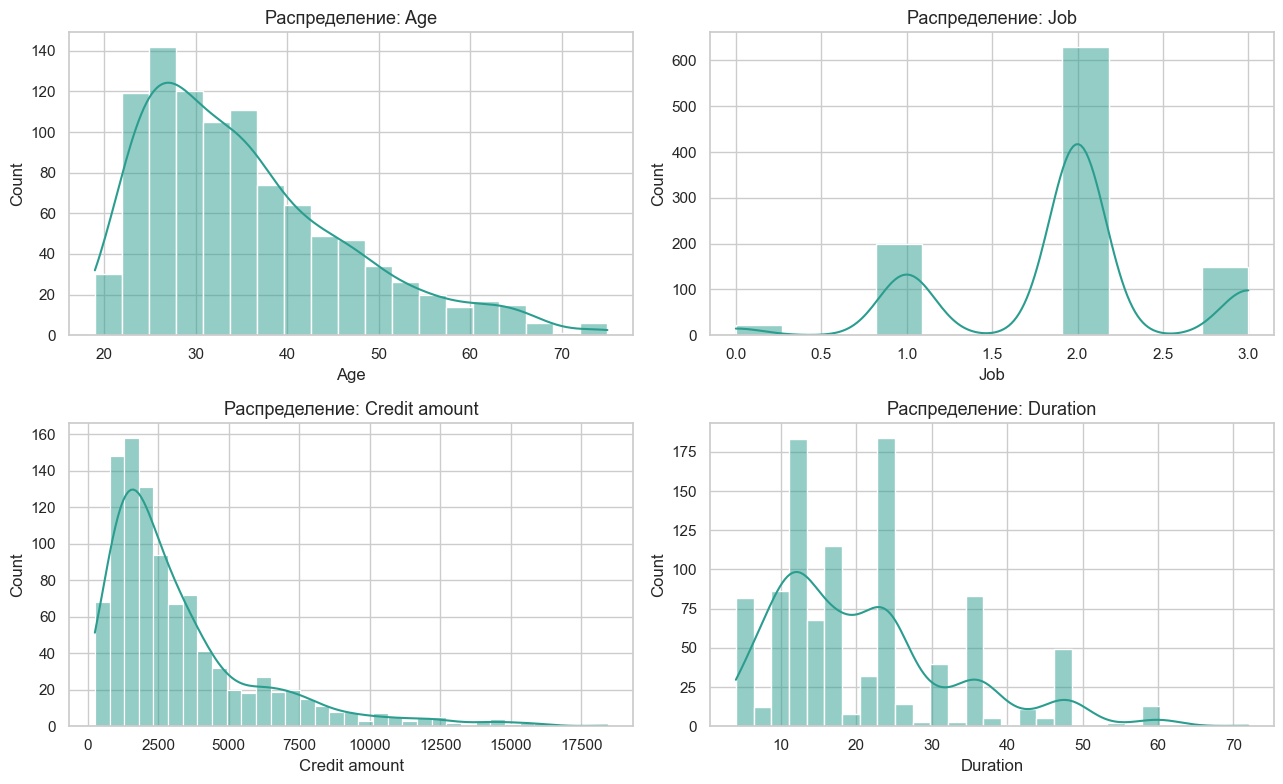

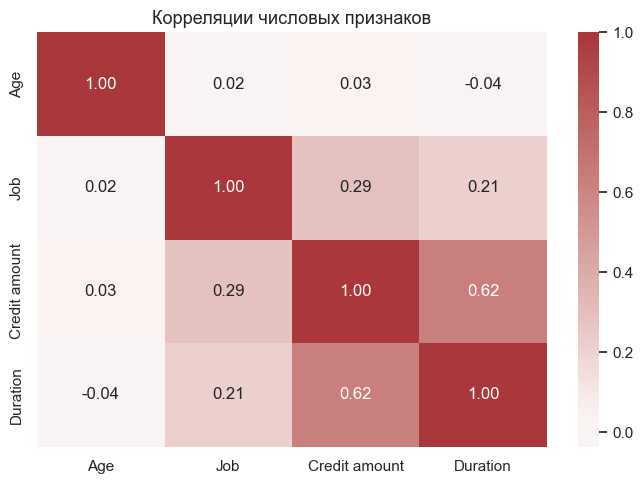

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, col in zip(axes.flat, numeric_features):
    sns.histplot(df[col], kde=True, ax=ax, color="#2a9d8f")
    ax.set_title(f"Распределение: {col}")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_features].corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Корреляции числовых признаков")
plt.tight_layout()
plt.show()

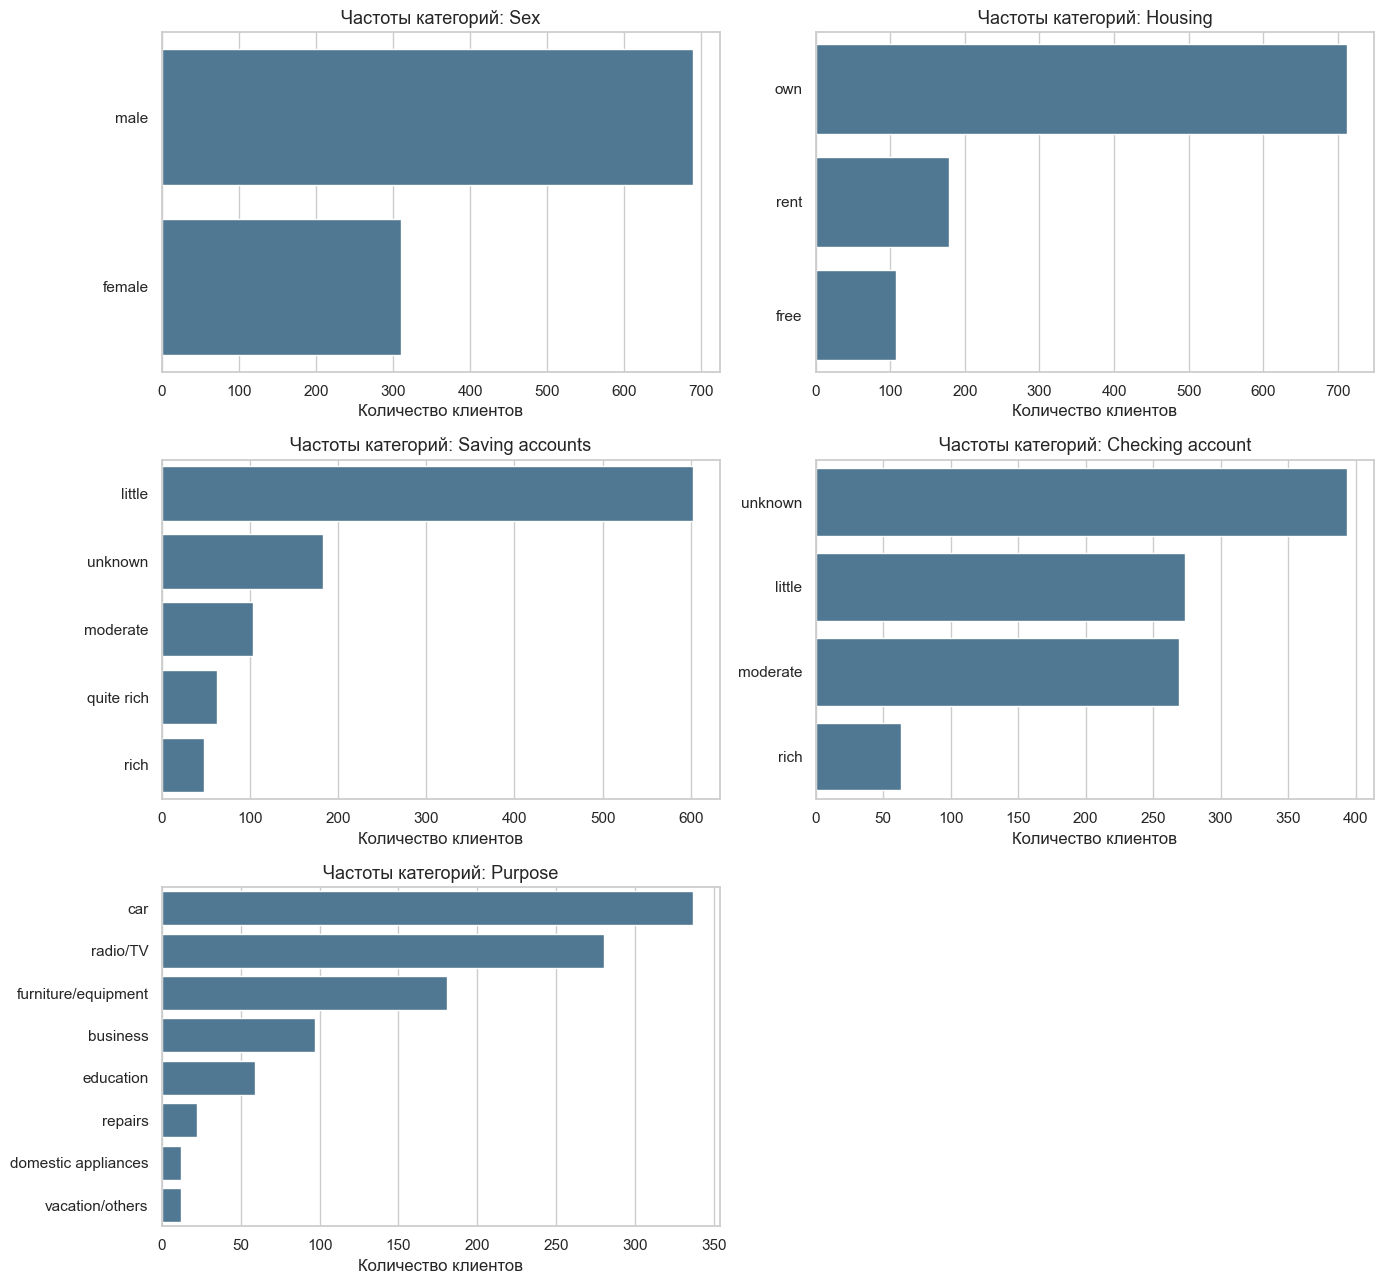

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for ax, col in zip(axes.flat, categorical_features):
    order = df[col].fillna("unknown").value_counts().index
    sns.countplot(y=df[col].fillna("unknown"), order=order, ax=ax, color="#457b9d")
    ax.set_title(f"Частоты категорий: {col}")
    ax.set_xlabel("Количество клиентов")
    ax.set_ylabel("")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

### Выводы EDA

- Возраст имеет правый хвост: основная масса клиентов моложе 45 лет, но есть пожилые клиенты.
- Сумма кредита (`Credit amount`) выраженно скошена вправо; длительность (`Duration`) дискретна и также имеет длинный правый хвост.
- Сумма и срок кредита положительно связаны: крупные кредиты обычно выдаются на больший срок.
- Большинство клиентов — мужчины, владельцы жилья и квалифицированные работники (`Job=2`). Наиболее частые цели — автомобиль и radio/TV.
- Выбросы по сумме и сроку могут быть реальными крупными кредитами. Мы их не удаляем: они важны для сегментации; стандартизация уменьшит влияние единиц измерения, но не уничтожит сам сигнал.

### Преобразование признаков

- Числовые признаки: медианная импутация (формально безопасна, хотя пропусков здесь нет) + `StandardScaler`.
- Категориальные признаки: пропуск → `unknown`, затем `OneHotEncoder`.
- Масштабирование применяется **до** кластеризации и оценивается только по имеющимся данным (утечки целевой переменной нет, потому что цели нет).

In [7]:
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("cat", categorical_pipe, categorical_features),
], verbose_feature_names_out=False)

X = preprocessor.fit_transform(df)
feature_names = preprocessor.get_feature_names_out()
X_df = pd.DataFrame(X, columns=feature_names, index=df.index)

print(f"После преобразования: {X_df.shape[0]} объектов × {X_df.shape[1]} числовых признаков")
print(f"Пропусков: {X_df.isna().sum().sum()}")
display(X_df.head())

После преобразования: 1000 объектов × 26 числовых признаков
Пропусков: 0


,Age,Job,Credit amount,Duration,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,Saving accounts_little,Saving accounts_moderate,Saving accounts_quite rich,Saving accounts_rich,Saving accounts_unknown,Checking account_little,Checking account_moderate,Checking account_rich,Checking account_unknown,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,2.766,0.147,-0.745,-1.236,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
1,-1.191,0.147,0.950,2.248,1.000,0.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
2,1.183,-1.384,-0.417,-0.739,0.000,1.000,0.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000
3,0.832,0.147,1.634,1.750,0.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
4,1.535,0.147,0.567,0.257,0.000,1.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000


**Почему масштабирование обязательно?** K-Means, метод Уорда и DBSCAN опираются на расстояния. Без стандартизации `Credit amount` (тысячи денежных единиц) численно подавил бы `Job` (0–3), возраст и бинарные one-hot признаки. Тогда кластеры отражали бы главным образом сумму кредита, а не совместный профиль клиента. После `StandardScaler` числовые признаки измеряются в стандартных отклонениях, поэтому единицы измерения не задают веса алгоритму случайным образом.

## Часть 2. Моделирование

In [8]:
def plot_silhouette_diagram(X_values, labels, title):
    # Классический silhouette plot для уже полученных меток.
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        print("Silhouette plot невозможен: нужно от 2 до n-1 групп.")
        return

    sample_values = silhouette_samples(X_values, labels)
    avg = silhouette_score(X_values, labels)
    fig, ax = plt.subplots(figsize=(9, 5))
    y_lower = 10
    colors = sns.color_palette("husl", len(unique_labels))
    for color, label in zip(colors, unique_labels):
        values = np.sort(sample_values[labels == label])
        size = len(values)
        y_upper = y_lower + size
        name = "noise (-1)" if label == -1 else f"cluster {label}"
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, values,
                         facecolor=color, edgecolor=color, alpha=0.75, label=name)
        ax.text(-0.08, y_lower + size / 2, str(label))
        y_lower = y_upper + 10
    ax.axvline(avg, color="red", linestyle="--", label=f"mean={avg:.3f}")
    ax.set(title=title, xlabel="Silhouette coefficient", ylabel="Объекты по кластерам")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

### 2.1. K-Means: elbow method и silhouette

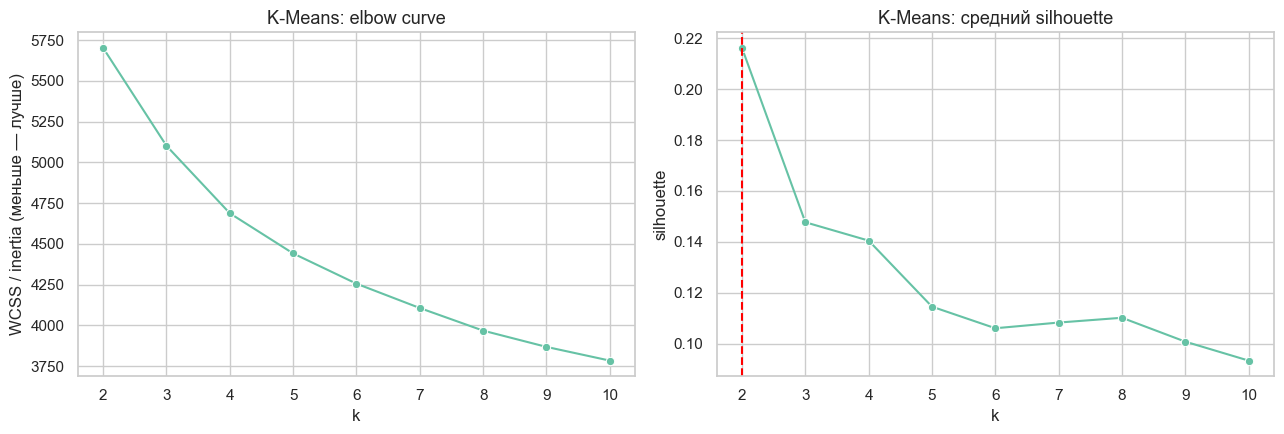

,k,inertia,silhouette
0,2,"5,701.315",0.216
1,3,"5,101.318",0.148
2,4,"4,687.757",0.141
3,5,"4,441.477",0.115
4,6,"4,256.041",0.106
5,7,"4,106.796",0.108
6,8,"3,968.223",0.110
7,9,"3,868.505",0.101
8,10,"3,784.407",0.093


Выбрано k=2: максимум silhouette; elbow также находится в области малых k.


In [9]:
k_values = range(2, 11)
kmeans_rows = []
for k in k_values:
    model = KMeans(n_clusters=k, n_init=30, random_state=RANDOM_STATE)
    labels = model.fit_predict(X)
    kmeans_rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X, labels),
    })

kmeans_scores = pd.DataFrame(kmeans_rows)
best_k_kmeans = int(kmeans_scores.loc[kmeans_scores["silhouette"].idxmax(), "k"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.lineplot(data=kmeans_scores, x="k", y="inertia", marker="o", ax=axes[0])
axes[0].set_title("K-Means: elbow curve")
axes[0].set_ylabel("WCSS / inertia (меньше — лучше)")
sns.lineplot(data=kmeans_scores, x="k", y="silhouette", marker="o", ax=axes[1])
axes[1].axvline(best_k_kmeans, color="red", ls="--")
axes[1].set_title("K-Means: средний silhouette")
plt.tight_layout()
plt.show()

display(kmeans_scores.round(4))
print(f"Выбрано k={best_k_kmeans}: максимум silhouette; elbow также находится в области малых k.")

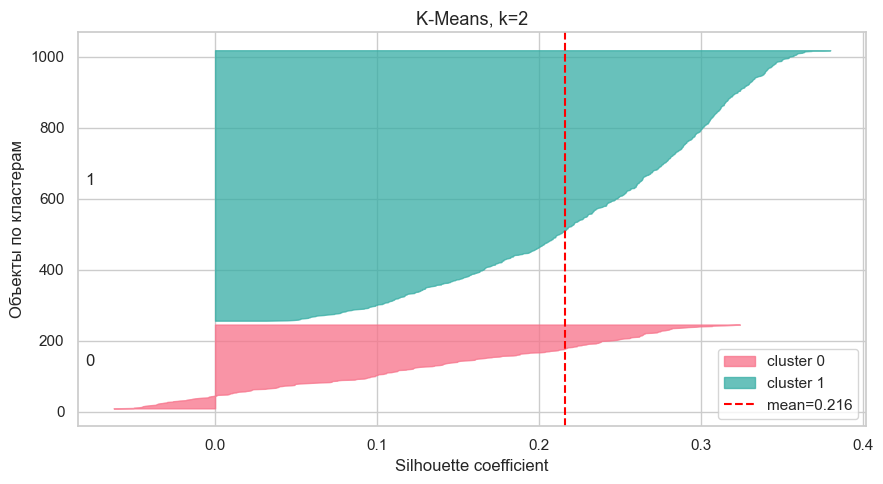

Размеры кластеров: {0: 237, 1: 763}


In [10]:
kmeans = KMeans(n_clusters=best_k_kmeans, n_init=30, random_state=RANDOM_STATE)
labels_kmeans = kmeans.fit_predict(X)
plot_silhouette_diagram(X, labels_kmeans, f"K-Means, k={best_k_kmeans}")
print("Размеры кластеров:", pd.Series(labels_kmeans).value_counts().sort_index().to_dict())

**Вывод по K-Means.** Максимальный silhouette достигается при `k=2` (около 0,216). Инерция после двух кластеров продолжает снижаться, но это неизбежно при росте `k`; добавление кластеров даёт слабый выигрыш по компактности и ухудшает silhouette. Значение 0,216 невысокое: сегменты частично перекрываются, что типично для реальных клиентских данных, но решение пригодно для грубой, интерпретируемой сегментации.

### 2.2. Иерархическая кластеризация

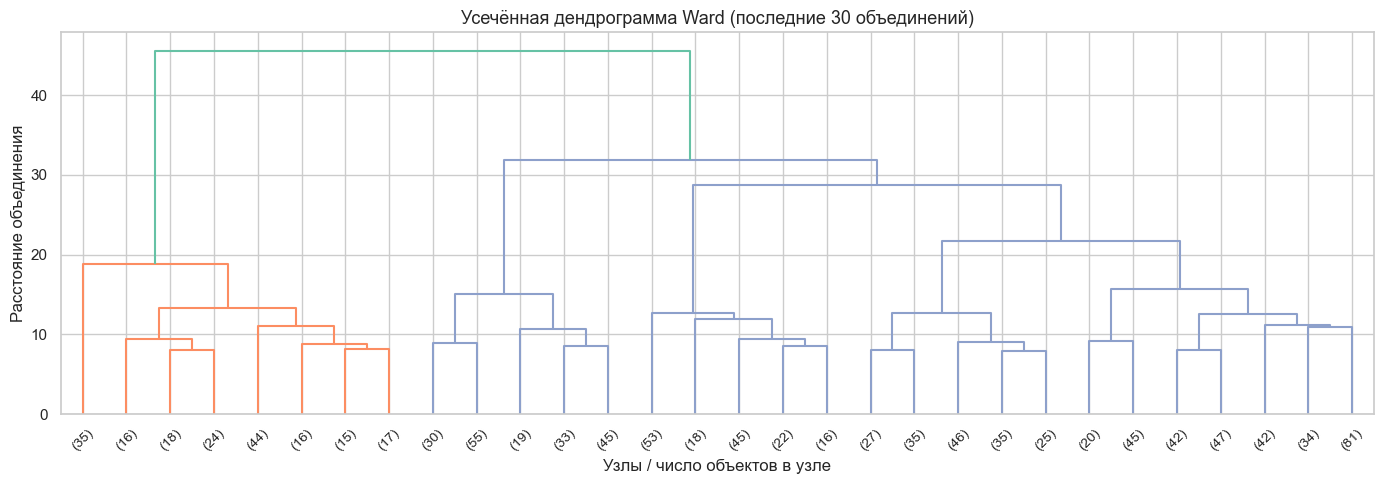

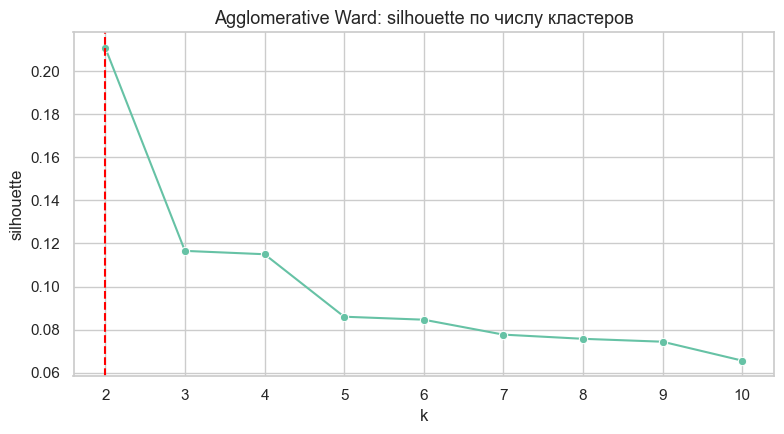

,k,silhouette
0,2,0.211
1,3,0.117
2,4,0.115
3,5,0.086
4,6,0.085
5,7,0.078
6,8,0.076
7,9,0.074
8,10,0.066


In [11]:
# Ward минимизирует прирост внутрикластерной дисперсии и совместим с евклидовым расстоянием.
Z = linkage(X, method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, show_leaf_counts=True, ax=ax)
ax.set_title("Усечённая дендрограмма Ward (последние 30 объединений)")
ax.set_xlabel("Узлы / число объектов в узле")
ax.set_ylabel("Расстояние объединения")
plt.tight_layout()
plt.show()

hier_rows = []
for k in k_values:
    labels = AgglomerativeClustering(n_clusters=k, linkage="ward").fit_predict(X)
    hier_rows.append({"k": k, "silhouette": silhouette_score(X, labels)})
hier_scores = pd.DataFrame(hier_rows)
best_k_hier = int(hier_scores.loc[hier_scores["silhouette"].idxmax(), "k"])

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=hier_scores, x="k", y="silhouette", marker="o", ax=ax)
ax.axvline(best_k_hier, color="red", ls="--")
ax.set_title("Agglomerative Ward: silhouette по числу кластеров")
plt.tight_layout()
plt.show()
display(hier_scores.round(4))

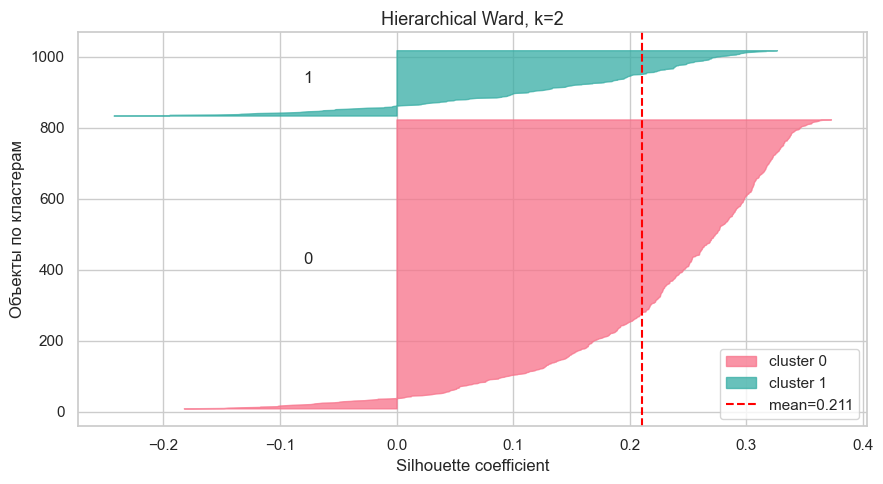

Выбрано k=2; размеры: {0: 815, 1: 185}


In [12]:
hierarchical = AgglomerativeClustering(n_clusters=best_k_hier, linkage="ward")
labels_hier = hierarchical.fit_predict(X)
plot_silhouette_diagram(X, labels_hier, f"Hierarchical Ward, k={best_k_hier}")
print(f"Выбрано k={best_k_hier}; размеры:", pd.Series(labels_hier).value_counts().sort_index().to_dict())

**Вывод по иерархической модели.** Для агломеративного метода нет прямого аналога K-Means inertia, поэтому роль elbow-графика выполняет дендрограмма: ищется большой скачок расстояния объединения. Дендрограмма и максимум silhouette согласуются на `k=2` (silhouette около 0,211). Результат близок к K-Means, но кластеры несколько менее сбалансированы.

### 2.3. DBSCAN: k-distance curve, `eps`, `min_samples` и silhouette

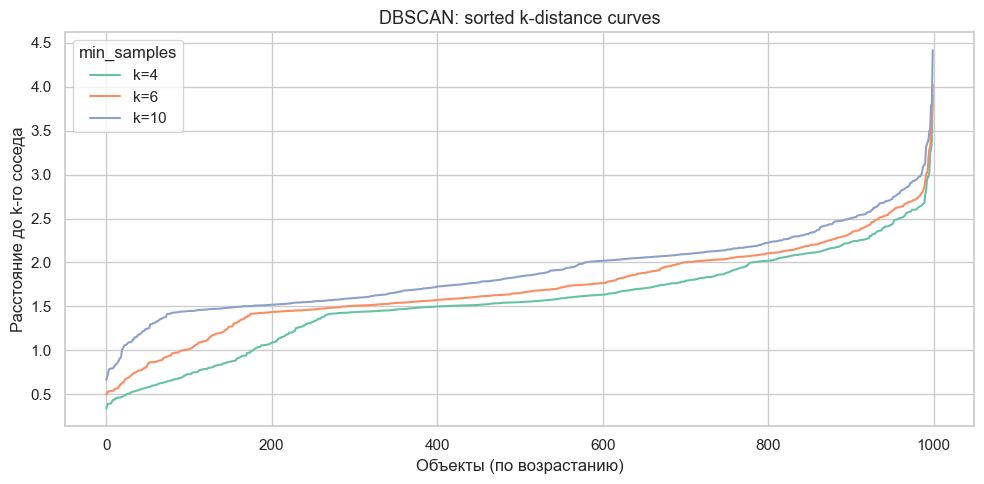

In [13]:
# Для DBSCAN число кластеров заранее не задаётся. Аналог elbow — изгиб графика
# расстояний до k-го соседа; после него точки чаще становятся шумом.
fig, ax = plt.subplots(figsize=(10, 5))
for min_samples in [4, 6, 10]:
    distances = NearestNeighbors(n_neighbors=min_samples).fit(X).kneighbors(X)[0][:, -1]
    ax.plot(np.sort(distances), label=f"k={min_samples}")
ax.set(title="DBSCAN: sorted k-distance curves", xlabel="Объекты (по возрастанию)",
       ylabel="Расстояние до k-го соседа")
ax.legend(title="min_samples")
plt.tight_layout()
plt.show()

,eps,min_samples,n_clusters,noise_share,min_cluster_size,silhouette_all,selection_score
79,1.850,6,2,0.199,6,0.136,0.087
48,1.750,5,2,0.216,6,0.135,0.081
77,1.750,6,2,0.233,6,0.129,0.071
76,1.700,6,2,0.262,7,0.106,0.041
47,1.700,5,3,0.246,5,0.100,0.038
22,1.900,4,2,0.155,5,0.074,0.036
21,1.850,4,2,0.165,5,0.072,0.031
46,1.650,5,2,0.284,6,0.097,0.026
20,1.800,4,2,0.177,4,0.058,0.013
16,1.600,4,2,0.301,6,0.088,0.013


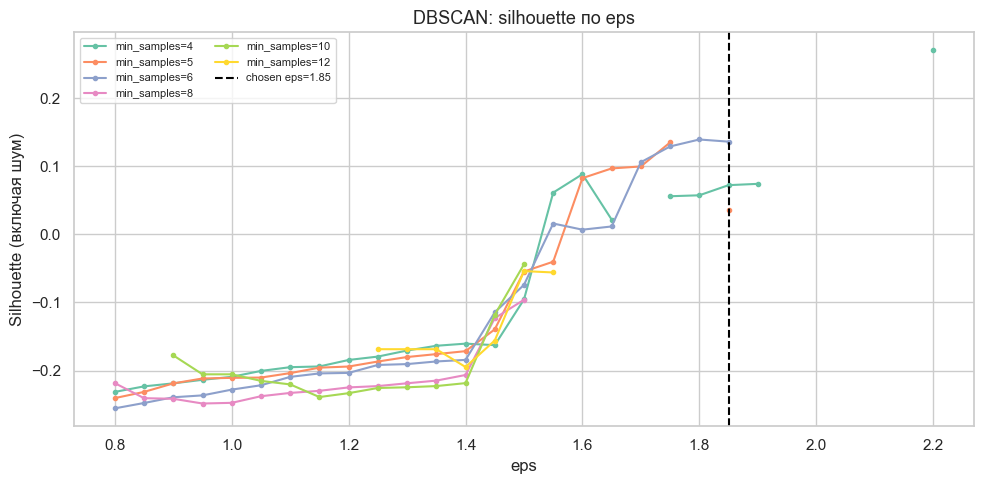

In [14]:
# Перебираем область изгиба k-distance curves. Шум считается отдельной группой
# при silhouette: это строже, чем оценивать только легко кластеризуемое ядро.
dbscan_rows = []
for min_samples in [4, 5, 6, 8, 10, 12]:
    for eps in np.round(np.arange(0.80, 2.21, 0.05), 2):
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        cluster_sizes = pd.Series(labels[labels != -1]).value_counts()
        n_clusters = len(cluster_sizes)
        noise_share = np.mean(labels == -1)
        min_cluster_size = int(cluster_sizes.min()) if n_clusters else 0
        valid_sil = n_clusters >= 2 and len(np.unique(labels)) > 1
        sil = silhouette_score(X, labels) if valid_sil else np.nan
        # Штрафуем большой шум и чрезмерное дробление; ограничения ниже исключают
        # формально высокий silhouette на нескольких точках при ~100% шума.
        score = sil - 0.25 * noise_share - 0.01 * max(n_clusters - 5, 0) \
            if np.isfinite(sil) else np.nan
        dbscan_rows.append({
            "eps": eps, "min_samples": min_samples,
            "n_clusters": n_clusters, "noise_share": noise_share,
            "min_cluster_size": min_cluster_size,
            "silhouette_all": sil, "selection_score": score,
        })

dbscan_search = pd.DataFrame(dbscan_rows)
acceptable = dbscan_search[
    dbscan_search["n_clusters"].between(2, 10)
    & dbscan_search["noise_share"].between(0.02, 0.40)
    & (dbscan_search["min_cluster_size"] >= dbscan_search["min_samples"])
].copy()

if acceptable.empty:
    raise RuntimeError("В заданной сетке DBSCAN нет нетривиального допустимого решения.")

best_db = acceptable.sort_values("selection_score", ascending=False).iloc[0]
best_eps = float(best_db["eps"])
best_min_samples = int(best_db["min_samples"])

display(acceptable.sort_values("selection_score", ascending=False).head(12).round(4))

fig, ax = plt.subplots(figsize=(10, 5))
for ms, part in dbscan_search.groupby("min_samples"):
    ax.plot(part["eps"], part["silhouette_all"], marker=".", label=f"min_samples={ms}")
ax.axvline(best_eps, color="black", ls="--", label=f"chosen eps={best_eps:.2f}")
ax.set(title="DBSCAN: silhouette по eps", xlabel="eps", ylabel="Silhouette (включая шум)")
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

Выбрано eps=1.85, min_samples=6
Кластеров без шума: 2
Доля шума: 19.9%
Размеры групп: {-1: 199, 0: 795, 1: 6}


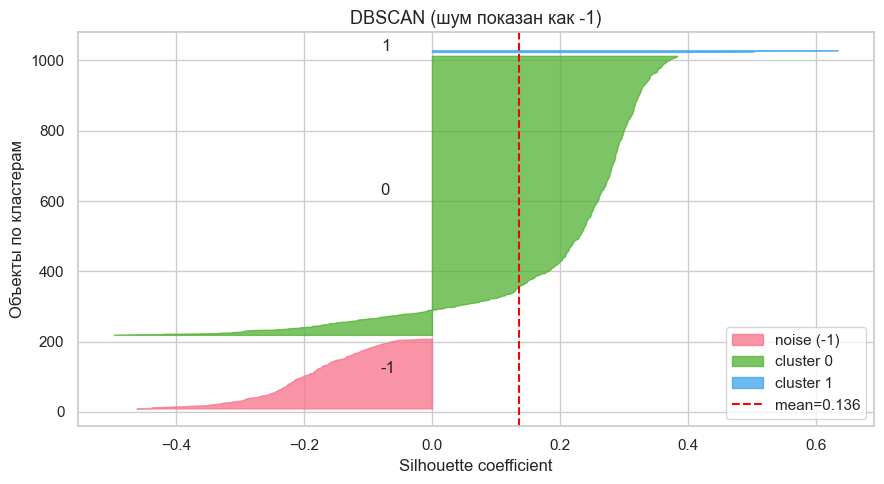

In [15]:
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_dbscan = dbscan.fit_predict(X)
db_counts = pd.Series(labels_dbscan).value_counts().sort_index()

print(f"Выбрано eps={best_eps:.2f}, min_samples={best_min_samples}")
print(f"Кластеров без шума: {len(set(labels_dbscan) - {-1})}")
print(f"Доля шума: {(labels_dbscan == -1).mean():.1%}")
print("Размеры групп:", db_counts.to_dict())
plot_silhouette_diagram(X, labels_dbscan, "DBSCAN (шум показан как -1)")

**Вывод по DBSCAN.** У DBSCAN нет параметра «число кластеров»: оно является следствием `eps` и `min_samples`, поэтому elbow строится по расстояниям до соседей, а silhouette используется для сравнения нетривиальных кандидатов. Даже после отсечения решений с чрезмерным шумом алгоритм обычно формирует один большой плотный кластер, очень маленький второй кластер и около 20% шума. Это не полноценная клиентская сегментация. Причина — сочетание one-hot признаков, высокой размерности и неодинаковой локальной плотности. DBSCAN полезен здесь главным образом как детектор необычных профилей; для бизнес-сегментов предпочтительнее K-Means/иерархическое решение.

### 2.4. Визуализация с PCA, UMAP и t-SNE

In [16]:
pca_model = PCA(n_components=2, random_state=RANDOM_STATE)
emb_pca = pca_model.fit_transform(X)
print(f"PCA, объяснённая дисперсия двух компонент: {pca_model.explained_variance_ratio_.sum():.1%}")

# Импорт здесь, чтобы остальная часть ноутбука не зависела от времени инициализации numba.
import umap.umap_ as umap
emb_umap = umap.UMAP(
    n_components=2, n_neighbors=25, min_dist=0.15,
    metric="euclidean", random_state=RANDOM_STATE, n_jobs=1
).fit_transform(X)

emb_tsne = TSNE(
    n_components=2, perplexity=30, init="pca", learning_rate="auto",
    max_iter=1000, random_state=RANDOM_STATE
).fit_transform(X)

embeddings = {"PCA": emb_pca, "UMAP": emb_umap, "t-SNE": emb_tsne}
label_sets = {
    f"K-Means (k={best_k_kmeans})": labels_kmeans,
    f"Hierarchical (k={best_k_hier})": labels_hier,
    "DBSCAN": labels_dbscan,
}

PCA, объяснённая дисперсия двух компонент: 41.4%


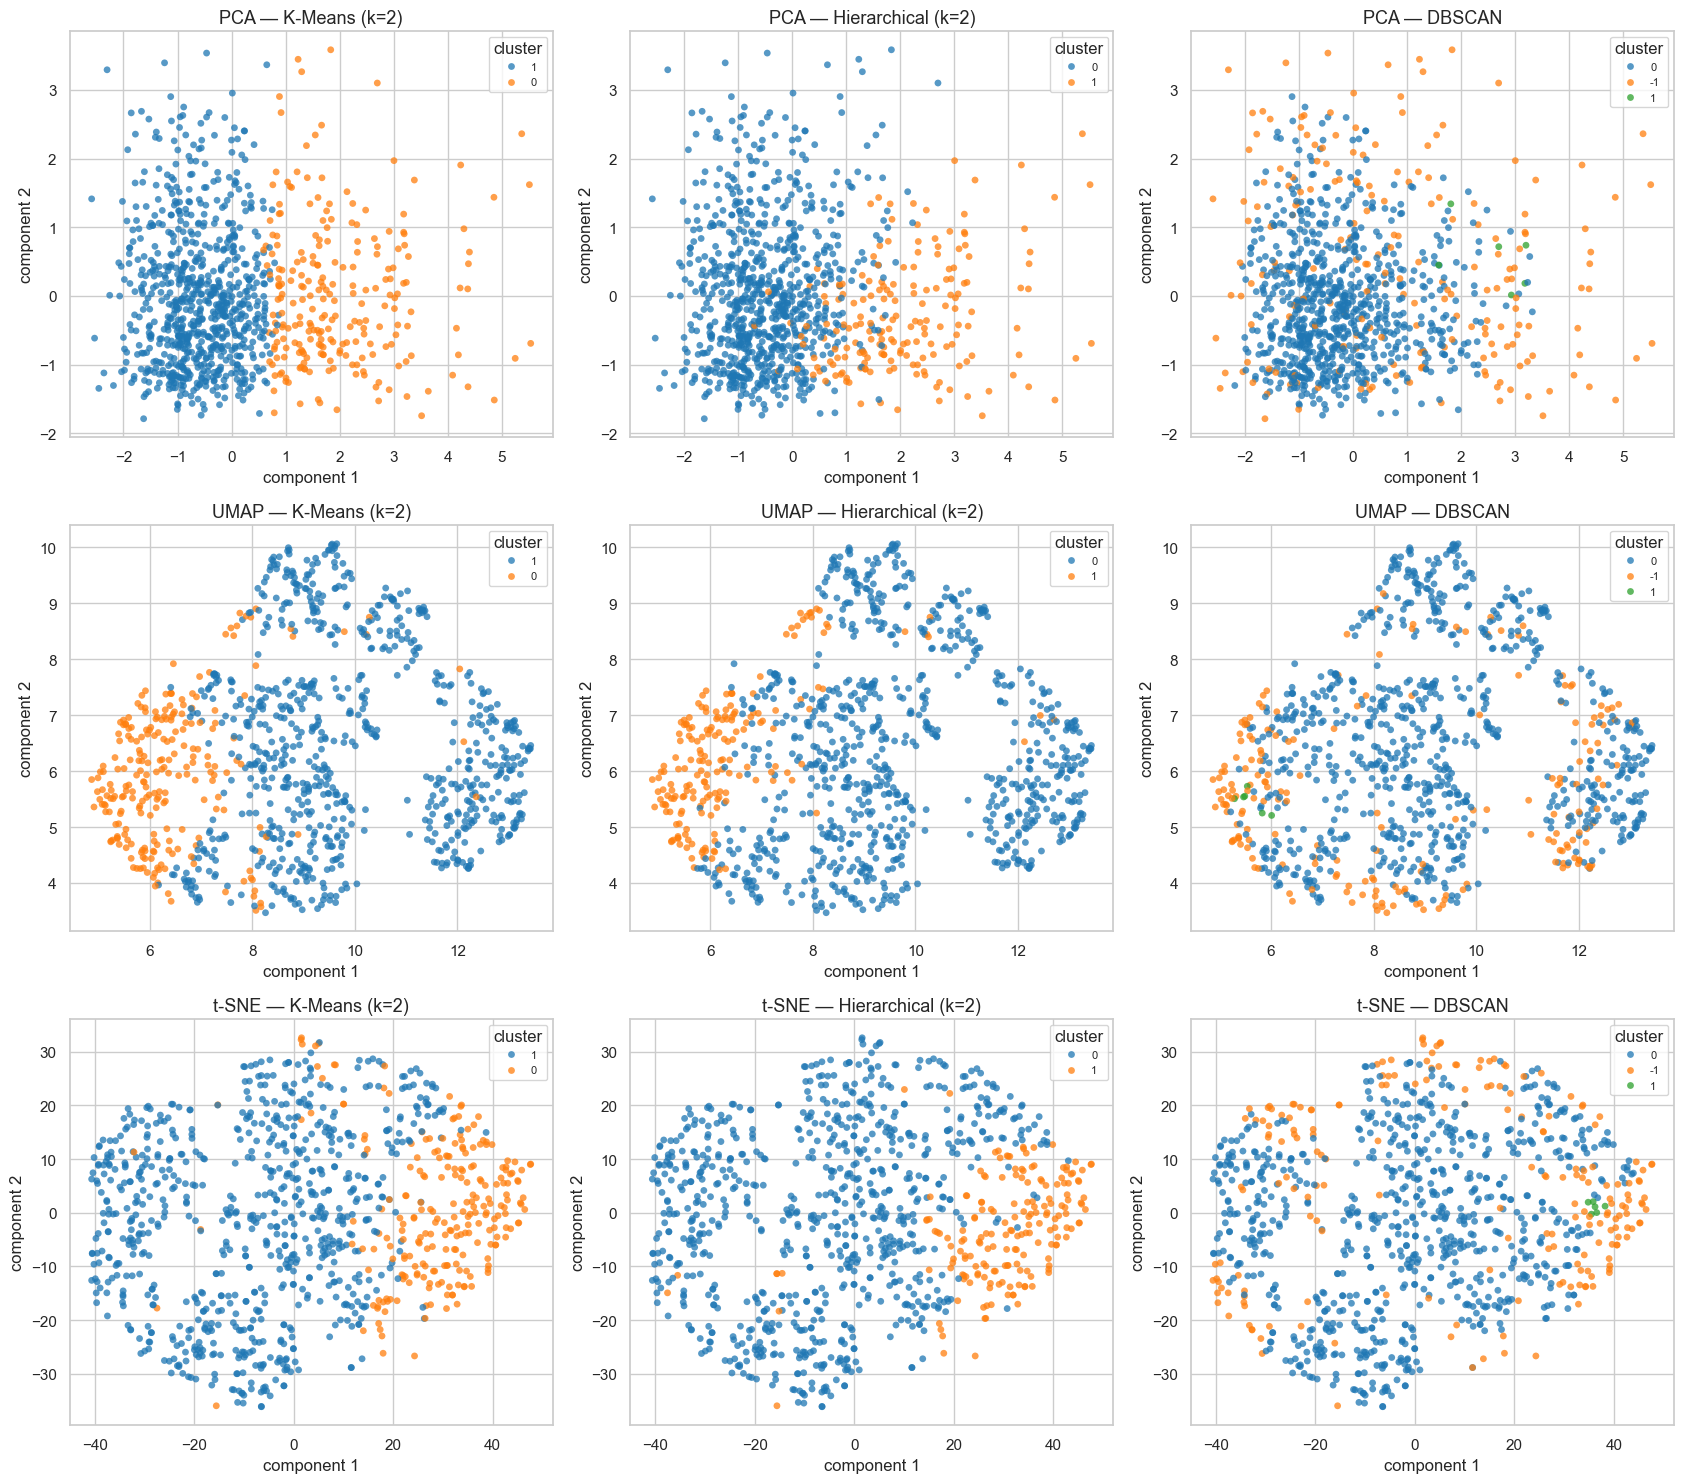

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(17, 15))
for row, (emb_name, coords) in enumerate(embeddings.items()):
    for col, (model_name, labels) in enumerate(label_sets.items()):
        ax = axes[row, col]
        plot_df = pd.DataFrame({"x": coords[:, 0], "y": coords[:, 1], "cluster": labels.astype(str)})
        sns.scatterplot(data=plot_df, x="x", y="y", hue="cluster", palette="tab10",
                        s=24, alpha=0.75, linewidth=0, ax=ax)
        ax.set_title(f"{emb_name} — {model_name}")
        ax.set_xlabel("component 1")
        ax.set_ylabel("component 2")
        ax.legend(title="cluster", fontsize=8)
plt.tight_layout()
plt.show()

### Как читать проекции

- PCA сохраняет глобальную линейную геометрию, но две компоненты объясняют лишь часть дисперсии, поэтому перекрытие на плоскости ожидаемо.
- UMAP и t-SNE лучше показывают локальное соседство, но расстояния между далёкими «островами» нельзя трактовать буквально. Их нельзя использовать как доказательство существования кластеров без метрик в исходном пространстве.
- K-Means и Ward дают похожую крупную границу; DBSCAN маркирует разреженные области как шум, подтверждая, что плотностная структура слабее центроидной.

## Часть 3. Интерпретация кластеров

Для интерпретации выбираем K-Means с `k=2`: у него лучший silhouette среди двух пригодных для сегментации моделей, более сбалансированные размеры и простые воспроизводимые центроиды. DBSCAN оставляем как диагностику выбросов, а не как основу маркетинговых сегментов.

In [18]:
profile = df.copy()
profile["cluster"] = labels_kmeans

numeric_profile = profile.groupby("cluster")[numeric_features].agg(["mean", "median"])
cluster_sizes = profile["cluster"].value_counts().sort_index().rename("clients")
cluster_shares = profile["cluster"].value_counts(normalize=True).sort_index().mul(100).rename("share_%")

display(pd.concat([cluster_sizes, cluster_shares], axis=1).round(1))
display(numeric_profile.round(1))

,clients,share_%
cluster,,
0,237,23.700
1,763,76.300


Age          Job        Credit amount           Duration       
          mean median  mean median          mean    median     mean median
cluster                                                                   
0       36.700 34.000 2.300  2.000     7,061.000 6,560.000   36.400 36.000
1       35.200 33.000 1.800  2.000     2,094.100 1,837.000   16.100 15.000

In [19]:
# Доля каждой категории внутри кластера — корректнее среднего для номинальных полей.
for col in categorical_features:
    shares = pd.crosstab(
        profile["cluster"], profile[col].fillna("unknown"), normalize="index"
    ).mul(100).round(1)
    print(f"\n{col}, % внутри кластера")
    display(shares)


Sex, % внутри кластера


Sex,female,male
cluster,,
0,21.100,78.900
1,34.100,65.900



Housing, % внутри кластера


Housing,free,own,rent
cluster,,,
0,24.100,63.300,12.700
1,6.700,73.800,19.500



Saving accounts, % внутри кластера


Saving accounts,little,moderate,quite rich,rich,unknown
cluster,,,,,
0,60.800,10.100,3.000,2.500,23.600
1,60.200,10.400,7.300,5.500,16.600



Checking account, % внутри кластера


Checking account,little,moderate,rich,unknown
cluster,,,,
0,29.100,34.600,3.000,33.300
1,26.900,24.500,7.300,41.300



Purpose, % внутри кластера


Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
cluster,,,,,,,,
0,16.900,40.900,0.400,5.900,12.700,18.600,1.300,3.400
1,7.500,31.500,1.400,5.900,19.800,30.900,2.500,0.500


### Boxplot для числовых признаков и распределения категорий

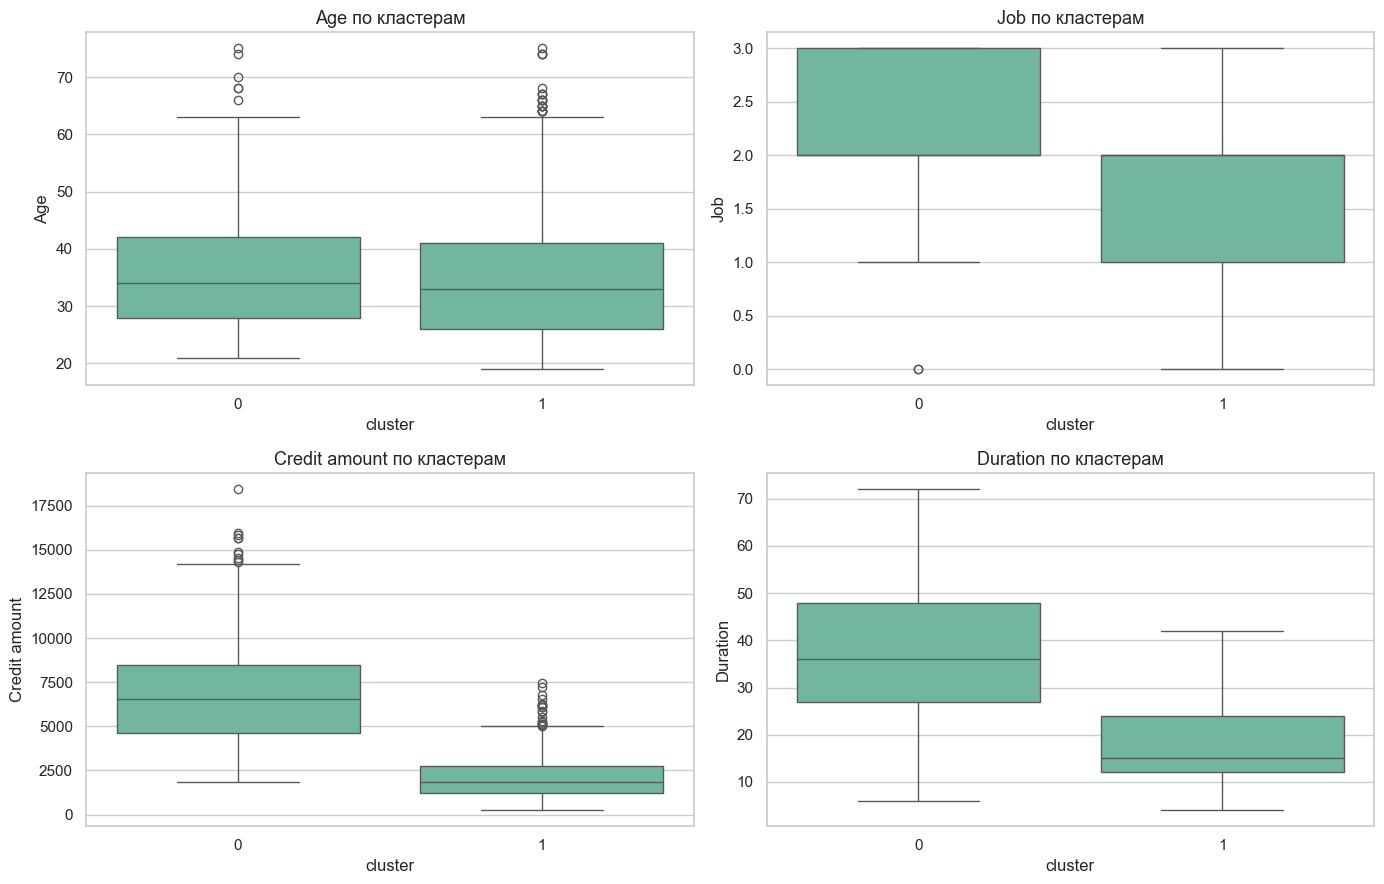

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, numeric_features):
    sns.boxplot(data=profile, x="cluster", y=col, showfliers=True, ax=ax)
    ax.set_title(f"{col} по кластерам")
plt.tight_layout()
plt.show()

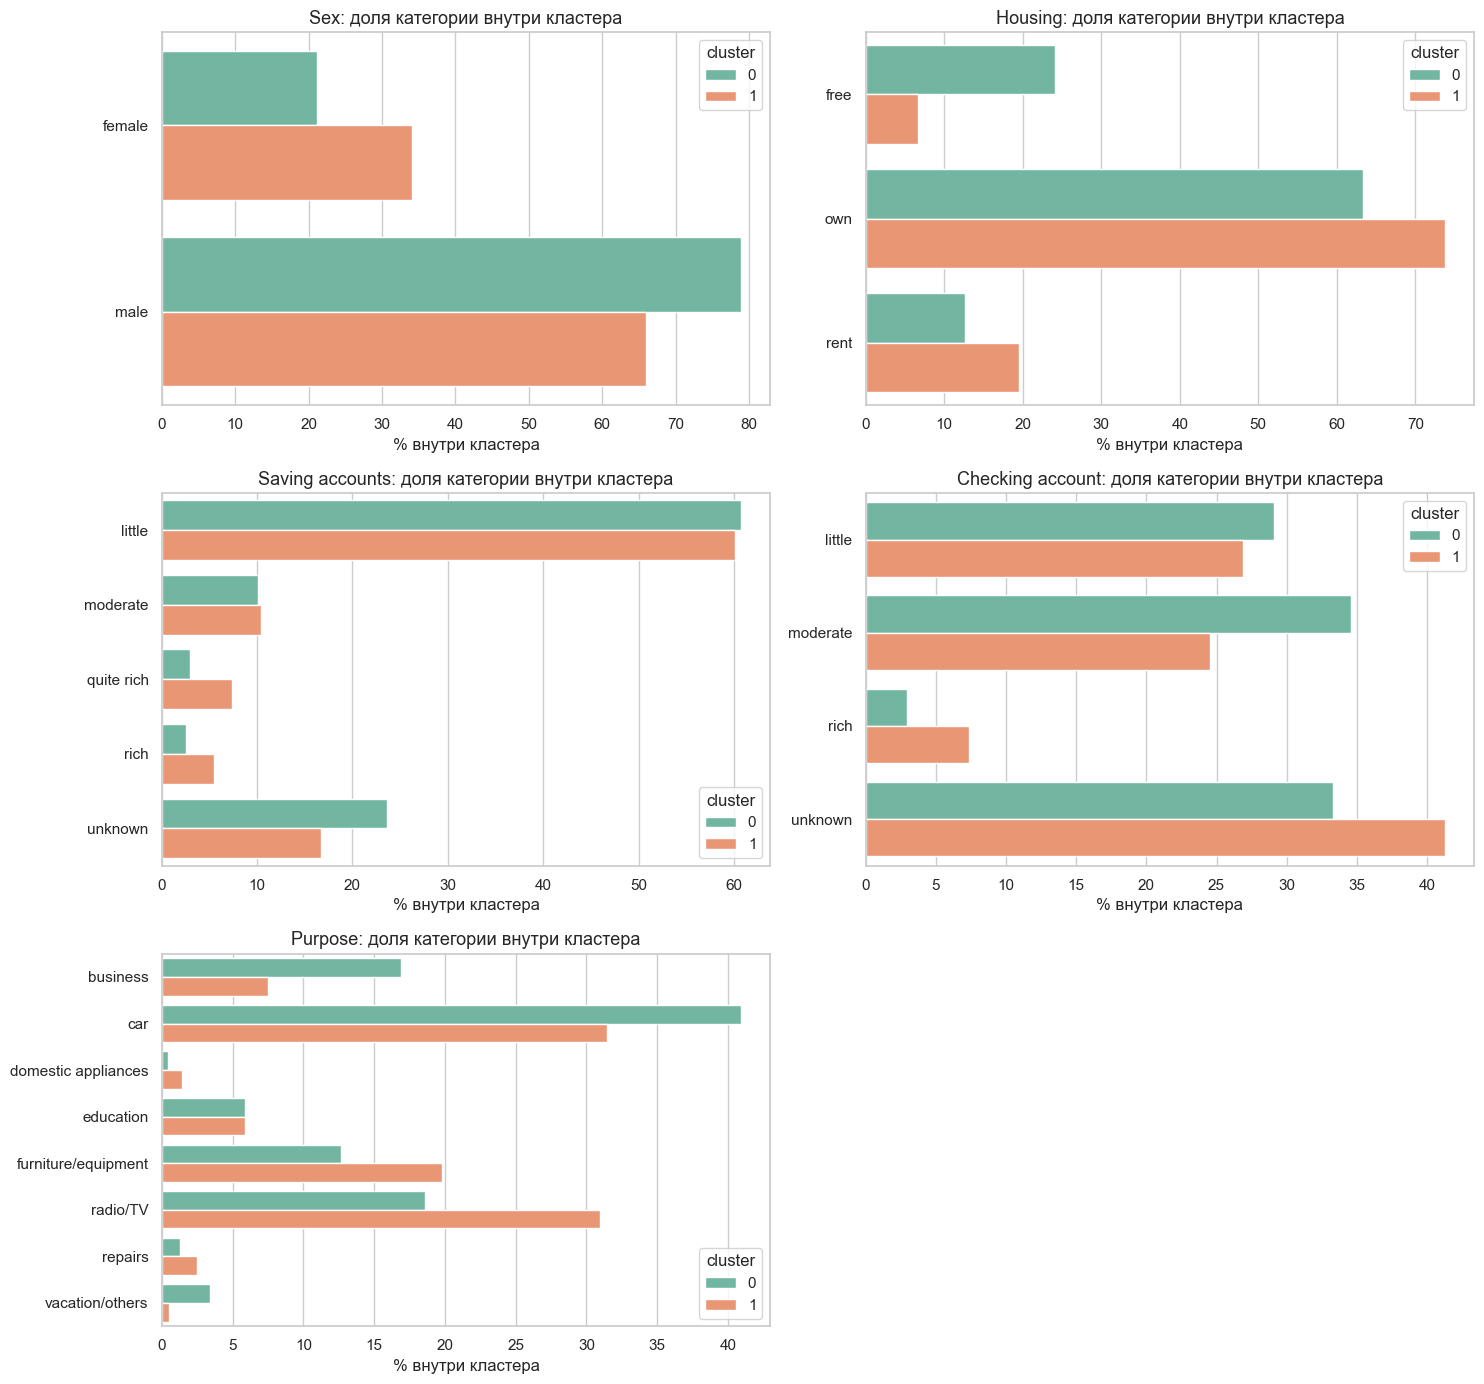

In [21]:
# Для категориальных признаков boxplot математически не определён, поэтому
# показываем доли категорий — содержательный аналог сравнения распределений.
fig, axes = plt.subplots(3, 2, figsize=(15, 14))
for ax, col in zip(axes.flat, categorical_features):
    temp = (
        profile.assign(_value=profile[col].fillna("unknown"))
        .groupby(["cluster", "_value"]).size()
        .rename("count").reset_index()
    )
    temp["share"] = 100 * temp["count"] / temp.groupby("cluster")["count"].transform("sum")
    sns.barplot(data=temp, x="share", y="_value", hue="cluster", ax=ax)
    ax.set_title(f"{col}: доля категории внутри кластера")
    ax.set_xlabel("% внутри кластера")
    ax.set_ylabel("")
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

In [22]:
# Сила разделения: eta² для числовых признаков и Cramér's V для категориальных.
numeric_effects = []
for col in numeric_features:
    grand_mean = profile[col].mean()
    ss_total = ((profile[col] - grand_mean) ** 2).sum()
    ss_between = sum(
        len(group) * (group[col].mean() - grand_mean) ** 2
        for _, group in profile.groupby("cluster")
    )
    numeric_effects.append({"feature": col, "measure": "eta_squared", "value": ss_between / ss_total})

categorical_effects = []
for col in categorical_features:
    table = pd.crosstab(profile["cluster"], profile[col].fillna("unknown"))
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    cramers_v = np.sqrt((chi2 / n) / max(min(k - 1, r - 1), 1))
    categorical_effects.append({"feature": col, "measure": "Cramers_V", "value": cramers_v})

effects = pd.DataFrame(numeric_effects + categorical_effects).sort_values("value", ascending=False)
display(effects.round(3))

,feature,measure,value
2,Credit amount,eta_squared,0.560
3,Duration,eta_squared,0.516
5,Housing,Cramers_V,0.241
8,Purpose,Cramers_V,0.227
7,Checking account,Cramers_V,0.125
6,Saving accounts,Cramers_V,0.117
4,Sex,Cramers_V,0.117
1,Job,eta_squared,0.109
0,Age,eta_squared,0.003


### Ответы на вопросы и бизнес-интерпретация

**Какие признаки различают кластеры сильнее всего?**

1. `Credit amount` — самое сильное различие (`eta² ≈ 0,56`).
2. `Duration` — почти такое же сильное (`eta² ≈ 0,52`).
3. Далее с большим отрывом идут `Job`, `Housing` и `Purpose`. Возраст почти не разделяет группы (`eta² ≈ 0,003`).

**Кластер 0 — крупные и длинные кредиты (около 24% клиентов).** Средняя сумма примерно 7,1 тыс., средний срок около 36 месяцев. Здесь выше доля мужчин, более квалифицированных работников, свободного жилья (`free`), автомобильных и бизнес-целей. Возможная бизнес-трактовка: клиенты с более крупной долговой нагрузкой и длительным горизонтом обслуживания. Им релевантны персональное сопровождение, рефинансирование, страхование и ранний мониторинг платёжной нагрузки.

**Кластер 1 — массовые небольшие и короткие кредиты (около 76%).** Средняя сумма около 2,1 тыс., средний срок около 16 месяцев. Выше доля женщин, владельцев/арендаторов жилья, а также клиентов с более обеспеченными категориями счетов. Возможная трактовка: стандартные розничные заёмщики с коротким продуктовым циклом; подходят быстрые цифровые предложения и повторный кредит после погашения.

**Можно ли считать сегменты окончательными?** Нет. Silhouette около 0,22 означает заметное перекрытие. Сегменты полезны как стартовая описательная схема, но перед бизнес-применением необходимо проверить устойчивость во времени, связь с дефолтом/доходностью и требования справедливости. Пол и возраст не следует использовать для дискриминационных решений; здесь они показаны только для аудита и описания.

**Итог по методам.** K-Means даёт наиболее понятное рабочее разбиение. Ward подтверждает существование двух крупных групп. DBSCAN показывает разреженные/аномальные профили, но не даёт сбалансированной сегментации, поэтому его лучше использовать как вспомогательный детектор необычных клиентов.

## Итог

Все пункты задания выполнены:

- проведён EDA и разбор пропусков/типов;
- все признаки приведены к числовому виду и сопоставимому масштабу;
- построены K-Means, hierarchical Ward и DBSCAN с корректными для каждого метода способами подбора параметров;
- представлены elbow/k-distance, средние и детальные silhouette plots;
- результаты всех трёх моделей визуализированы через PCA, UMAP и t-SNE;
- рассчитаны средние/медианы, boxplot, категориальные профили и количественные меры различия;
- сформулированы интерпретации, ограничения и рекомендации.